# Module 3 - Example data in R

In [1]:
###################
#RHC Example

#install packages
install.packages("tableone")
install.packages("Matching")

#load packages
library(tableone)
library(Matching)

#read in data
# SCOTT Data not at this location anymore
# load(url("http://biostat.mc.vanderbilt.edu/wiki/pub/Main/DataSets/rhc.sav"))
load(url("https://hbiostat.org/data/repo/rhc.sav"))
#view data
View(rhc)

#treatment variables is swang1
#x variables that we will use
#cat1: primary disease category
#age
#sex
#meanbp1: mean blood pressure

#create a data set with just these variables, for simplicity
ARF<-as.numeric(rhc$cat1=='ARF')
CHF<-as.numeric(rhc$cat1=='CHF')
Cirr<-as.numeric(rhc$cat1=='Cirrhosis')
colcan<-as.numeric(rhc$cat1=='Colon Cancer')
Coma<-as.numeric(rhc$cat1=='Coma')
COPD<-as.numeric(rhc$cat1=='COPD')
lungcan<-as.numeric(rhc$cat1=='Lung Cancer')
MOSF<-as.numeric(rhc$cat1=='MOSF w/Malignancy')
sepsis<-as.numeric(rhc$cat1=='MOSF w/Sepsis')
female<-as.numeric(rhc$sex=='Female')
died<-as.numeric(rhc$death=='Yes')
age<-rhc$age
treatment<-as.numeric(rhc$swang1=='RHC')
meanbp1<-rhc$meanbp1

#new dataset
mydata<-cbind(ARF,CHF,Cirr,colcan,Coma,lungcan,MOSF,sepsis,
              age,female,meanbp1,treatment,died)
mydata<-data.frame(mydata)

#covariates we will use (shorter list than you would use in practice)
xvars<-c("ARF","CHF","Cirr","colcan","Coma","lungcan","MOSF","sepsis",
         "age","female","meanbp1")

#look at a table 1
table1<- CreateTableOne(vars=xvars,strata="treatment", data=mydata, test=FALSE)
## include standardized mean difference (SMD)
print(table1,smd=TRUE)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Loading required package: MASS

## 
##  Matching (Version 4.10-15, Build Date: 2024-10-14)
##  See https://www.jsekhon.com for additional documentation.
##  Please cite software as:
##   Jasjeet S. Sekhon. 2011. ``Multivariate and Propensity Score Matching
##   Software with Automated Balance Optimization: The Matching package for R.''
##   Journal of Statistical Software, 42(7): 1-52. 
##




,cat1,cat2,ca,sadmdte,dschdte,dthdte,lstctdte,death,cardiohx,chfhx,⋯,meta,hema,seps,trauma,ortho,adld3p,urin1,race,income,ptid
,<fct>,<fct>,<fct>,<labelled>,<labelled>,<labelled>,<labelled>,<fct>,<labelled>,<labelled>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<labelled>,<labelled>,<fct>,<fct>,<labelled>
1,COPD,NA,Yes,11142,11151,NA,11382,No,0,0,⋯,No,No,No,No,No,0,NA,white,Under $11k,00005
2,MOSF w/Sepsis,NA,No,11799,11844,11844,11844,Yes,1,1,⋯,No,No,Yes,No,No,NA,1437,white,Under $11k,00007
3,MOSF w/Malignancy,MOSF w/Sepsis,Yes,12083,12143,NA,12400,No,0,0,⋯,No,No,No,No,No,NA,599,white,$25-$50k,00009
4,ARF,NA,No,11146,11183,11183,11182,Yes,0,0,⋯,No,No,No,No,No,NA,NA,white,$11-$25k,00010
5,MOSF w/Sepsis,NA,No,12035,12037,12037,12036,Yes,0,0,⋯,No,No,No,No,No,NA,64,white,Under $11k,00011
6,COPD,NA,No,12389,12396,NA,12590,No,0,1,⋯,No,No,No,No,No,0,242,white,Under $11k,00012
7,MOSF w/Malignancy,NA,Metastatic,12381,12423,NA,12616,No,0,0,⋯,No,No,No,No,No,NA,4465,white,$25-$50k,00013
8,ARF,Coma,No,11453,11487,11491,11490,Yes,0,0,⋯,No,No,Yes,No,No,NA,NA,white,$25-$50k,00014
9,MOSF w/Malignancy,NA,Yes,12426,12437,NA,12560,No,0,0,⋯,No,Yes,No,No,No,NA,5525,white,Under $11k,00016


                     Stratified by treatment
                      0             1             SMD   
  n                    3551          2184               
  ARF (mean (SD))      0.45 (0.50)   0.42 (0.49)   0.059
  CHF (mean (SD))      0.07 (0.25)   0.10 (0.29)   0.095
  Cirr (mean (SD))     0.05 (0.22)   0.02 (0.15)   0.145
  colcan (mean (SD))   0.00 (0.04)   0.00 (0.02)   0.038
  Coma (mean (SD))     0.10 (0.29)   0.04 (0.20)   0.207
  lungcan (mean (SD))  0.01 (0.10)   0.00 (0.05)   0.095
  MOSF (mean (SD))     0.07 (0.25)   0.07 (0.26)   0.018
  sepsis (mean (SD))   0.15 (0.36)   0.32 (0.47)   0.415
  age (mean (SD))     61.76 (17.29) 60.75 (15.63)  0.061
  female (mean (SD))   0.46 (0.50)   0.41 (0.49)   0.093
  meanbp1 (mean (SD)) 84.87 (38.87) 68.20 (34.24)  0.455


In [2]:
############################################
#do greedy matching on Mahalanobis distance
############################################

greedymatch<-Match(Tr=treatment,M=1,X=mydata[xvars],replace=FALSE)
matched<-mydata[unlist(greedymatch[c("index.treated","index.control")]), ]

#get table 1 for matched data with standardized differences
matchedtab1<-CreateTableOne(vars=xvars, strata ="treatment", 
                            data=matched, test = FALSE)
print(matchedtab1, smd = TRUE)

#outcome analysis
y_trt<-matched$died[matched$treatment==1]
y_con<-matched$died[matched$treatment==0]

#pairwise difference
diffy<-y_trt-y_con

#paired t-test
t.test(diffy)

#McNemar test
table(y_trt,y_con)

mcnemar.test(matrix(c(973,513,395,303),2,2))

                     Stratified by treatment
                      0             1             SMD   
  n                    2184          2184               
  ARF (mean (SD))      0.42 (0.49)   0.42 (0.49)   0.006
  CHF (mean (SD))      0.10 (0.29)   0.10 (0.29)  <0.001
  Cirr (mean (SD))     0.02 (0.15)   0.02 (0.15)  <0.001
  colcan (mean (SD))   0.00 (0.02)   0.00 (0.02)  <0.001
  Coma (mean (SD))     0.04 (0.20)   0.04 (0.20)  <0.001
  lungcan (mean (SD))  0.00 (0.05)   0.00 (0.05)  <0.001
  MOSF (mean (SD))     0.07 (0.26)   0.07 (0.26)  <0.001
  sepsis (mean (SD))   0.24 (0.43)   0.32 (0.47)   0.177
  age (mean (SD))     61.53 (16.15) 60.75 (15.63)  0.049
  female (mean (SD))   0.44 (0.50)   0.41 (0.49)   0.042
  meanbp1 (mean (SD)) 73.12 (34.28) 68.20 (34.24)  0.144



	One Sample t-test

data:  diffy
t = 3.9289, df = 2183, p-value = 8.799e-05
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 0.02706131 0.08099730
sample estimates:
mean of x 
0.0540293 


     y_con
y_trt   0   1
    0 303 395
    1 513 973


	McNemar's Chi-squared test with continuity correction

data:  matrix(c(973, 513, 395, 303), 2, 2)
McNemar's chi-squared = 15.076, df = 1, p-value = 0.0001033


# Matching on propesity Scores
# Scott added this cell to do the activity as in the lecture

MatchIt does the glm regression for you, so don't nee the processing above for this lecture example.

In [3]:
install.packages("MatchIt")
library(MatchIt)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done




Call:
matchit(formula = treatment ~ ARF + CHF + Cirr + colcan + Coma + 
    MOSF + sepsis + age + female + meanbp1, data = mydata, method = "nearest")

Summary of Balance for All Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.4456        0.3410          0.7374     0.8646    0.1905
ARF             0.4162        0.4452         -0.0589          .    0.0290
CHF             0.0957        0.0696          0.0889          .    0.0261
Cirr            0.0224        0.0493         -0.1813          .    0.0268
colcan          0.0005        0.0017         -0.0576          .    0.0012
Coma            0.0435        0.0960         -0.2575          .    0.0525
MOSF            0.0723        0.0679          0.0173          .    0.0045
sepsis          0.3205        0.1484          0.3688          .    0.1721
age            60.7498       61.7609         -0.0647     0.8175    0.0285
female          0.4148        0.4610         -0.0937          .    0.0462


To identify the units, use first mouse button; to stop, use second.


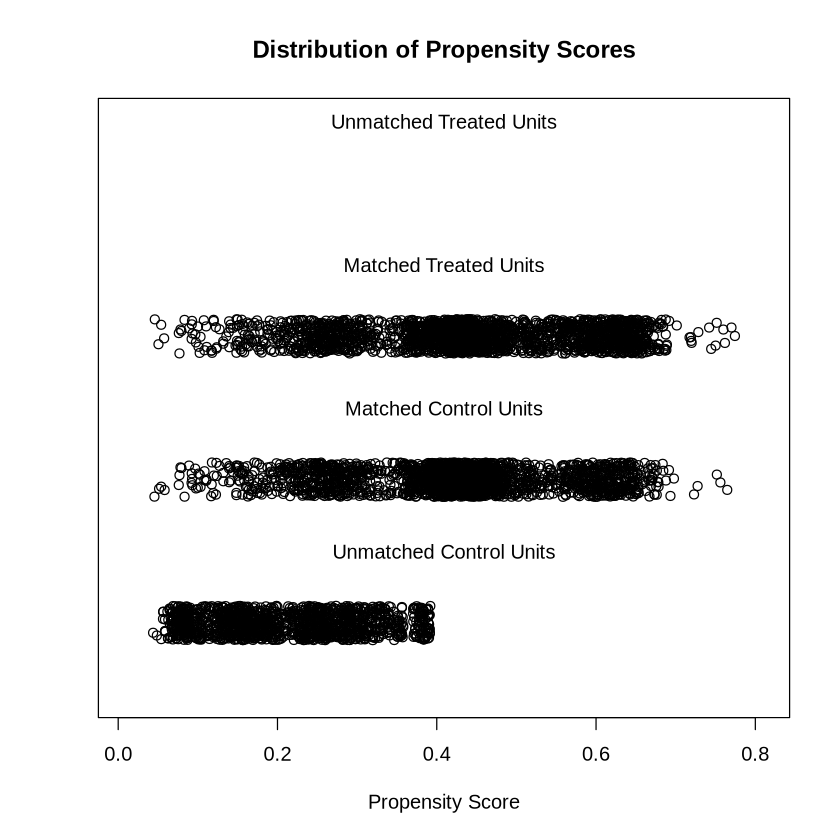

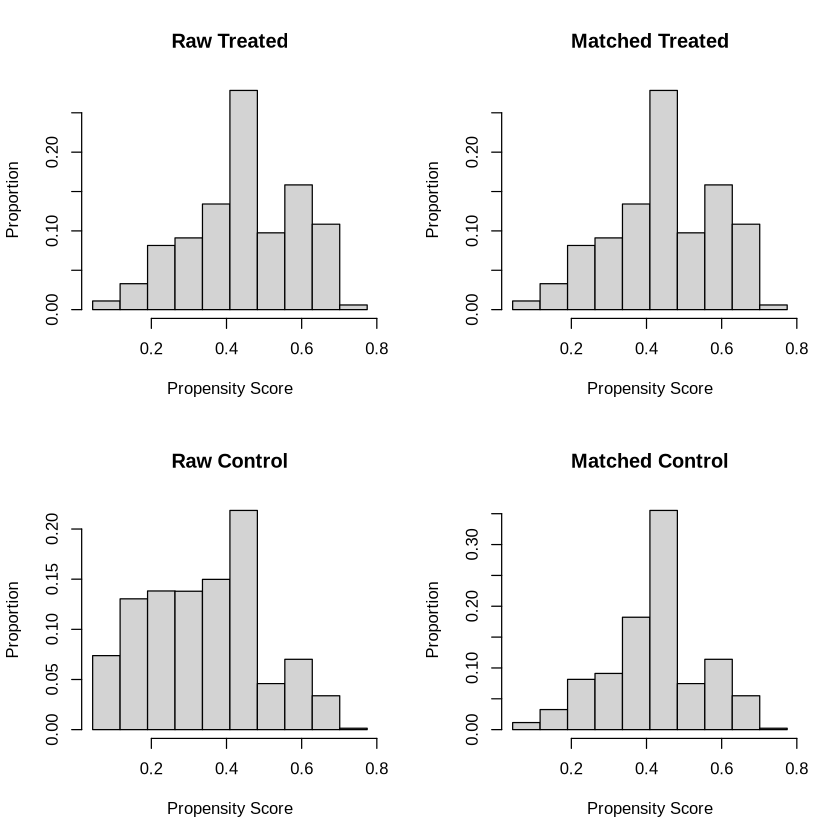

In [4]:
m.out <- matchit(treatment ~ ARF+CHF+Cirr+colcan+Coma+MOSF+sepsis+age+female+meanbp1, method="nearest", data=mydata)
summary(m.out)
plot(m.out, type="jitter")
plot(m.out, type="hist")

In [5]:
##########################
#propensity score matching
#########################

#fit a propensity score model. logistic regression

#SCOTT: aps1 column not in this data set?
#psmodel<-glm(treatment~ARF+CHF+Cirr+colcan+Coma+lungcan+MOSF+
#               sepsis+age+female+meanbp1+aps1,
#    family=binomial(),data=mydata)

psmodel<-glm(treatment~ARF+CHF+Cirr+colcan+Coma+lungcan+MOSF+
               sepsis+age+female+meanbp1,
    family=binomial(),data=mydata)

#show coefficients etc
summary(psmodel)
#create propensity score
pscore<-psmodel$fitted.values


Call:
glm(formula = treatment ~ ARF + CHF + Cirr + colcan + Coma + 
    lungcan + MOSF + sepsis + age + female + meanbp1, family = binomial(), 
    data = mydata)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -0.7299670  0.1997692  -3.654 0.000258 ***
ARF          1.2931956  0.1487784   8.692  < 2e-16 ***
CHF          1.6804704  0.1715672   9.795  < 2e-16 ***
Cirr         0.5234506  0.2181458   2.400 0.016416 *  
colcan       0.0295468  1.0985361   0.027 0.978542    
Coma         0.7013451  0.1854937   3.781 0.000156 ***
lungcan     -0.0869570  0.5039331  -0.173 0.863000    
MOSF         1.3046587  0.1772705   7.360 1.84e-13 ***
sepsis       2.0433604  0.1545437  13.222  < 2e-16 ***
age         -0.0031374  0.0017289  -1.815 0.069567 .  
female      -0.1697903  0.0583574  -2.909 0.003620 ** 
meanbp1     -0.0109824  0.0008217 -13.366  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial fam

In [6]:
#do greedy matching on logit(PS) using Match with a caliper

logit <- function(p) {log(p)-log(1-p)}
psmatch<-Match(Tr=mydata$treatment,M=1,X=logit(pscore),replace=FALSE,caliper=.2)
matched<-mydata[unlist(psmatch[c("index.treated","index.control")]), ]
xvars<-c("ARF","CHF","Cirr","colcan","Coma","lungcan","MOSF","sepsis",
         "age","female","meanbp1")

#get standardized differences
matchedtab1<-CreateTableOne(vars=xvars, strata ="treatment", 
                            data=matched, test = FALSE)
print(matchedtab1, smd = TRUE)

#outcome analysis
y_trt<-matched$died[matched$treatment==1]
y_con<-matched$died[matched$treatment==0]

#pairwise difference
diffy<-y_trt-y_con

#paired t-test
t.test(diffy)

                     Stratified by treatment
                      0             1             SMD   
  n                    1932          1932               
  ARF (mean (SD))      0.48 (0.50)   0.47 (0.50)   0.022
  CHF (mean (SD))      0.09 (0.29)   0.09 (0.29)   0.009
  Cirr (mean (SD))     0.03 (0.16)   0.03 (0.16)   0.003
  colcan (mean (SD))   0.00 (0.03)   0.00 (0.02)   0.019
  Coma (mean (SD))     0.05 (0.21)   0.05 (0.22)   0.007
  lungcan (mean (SD))  0.00 (0.05)   0.00 (0.05)   0.011
  MOSF (mean (SD))     0.08 (0.27)   0.08 (0.27)   0.015
  sepsis (mean (SD))   0.25 (0.43)   0.25 (0.43)   0.001
  age (mean (SD))     60.82 (17.89) 60.91 (15.51)  0.006
  female (mean (SD))   0.43 (0.50)   0.43 (0.49)   0.013
  meanbp1 (mean (SD)) 71.64 (34.09) 70.99 (35.02)  0.019



	One Sample t-test

data:  diffy
t = 2.8654, df = 1931, p-value = 0.00421
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 0.01339346 0.07149267
sample estimates:
 mean of x 
0.04244306 
